In [13]:
from pathlib import Path 
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / 'analysis').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / 'analysis' / 'calculate_kpis.py').exists() ,(f"could not find Cadence Focus from {Path.cwd()}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.calculate_kpis import (
    load_reporting_data,
    add_calculated_kpis,
    create_kpi_summary,
)

import analysis.calculate_kpis as kpi

df = load_reporting_data()

analysis_df = add_calculated_kpis(df)

kpi_summary = create_kpi_summary(analysis_df)

kpi_summary

,kpi,prior,current,change,unit
0,Cash,6.945326e+06,9.698804e+06,2.753478e+06,GBP
1,Profit / (loss),2.000139e+06,-6.407560e+05,-2.640895e+06,GBP
2,Net current position,-2.996933e+06,-3.707458e+06,-7.105250e+05,GBP
3,Current ratio,7.299204e-01,7.930269e-01,6.310650e-02,x
4,Debtors,1.154220e+06,4.506488e+06,3.352268e+06,GBP
5,Net assets,5.438743e+06,4.797987e+06,-6.407560e+05,GBP


In [21]:
## Derived KPIs
'''
Calculate current liabilities from reported current assets and the net current
position.

Current liabilities = Current assets − Net current assets
'''

'\nCalculate current liabilities from reported current assets and the net current\nposition.\n\nCurrent liabilities = Current assets − Net current assets\n'

In [2]:
analysis_df = df.copy()

analysis_df['current_liabilities'] = (
    analysis_df['current_assets'] - analysis_df['net_current_assets'])

missing_values_check = (
    analysis_df["current_liabilities"]
    .notna()
    .all()
)

non_negative_check = (
    analysis_df["current_liabilities"] >= 0
).all()

print("No missing values:", missing_values_check)
print("No negative values:", non_negative_check)

No missing values: True
No negative values: True


In [40]:
### Current ratio
'''
The current ratio measures short-term balance-sheet coverage.

Current ratio = Current assets ÷ Current liabilities
'''

'\nThe current ratio measures short-term balance-sheet coverage.\n\nCurrent ratio = Current assets ÷ Current liabilities\n'

In [3]:
non_zero_denominator_check = (
    analysis_df["current_liabilities"] != 0).all()

print("Liabilities is non-zero:", non_zero_denominator_check)

analysis_df['current_ratio'] = (analysis_df['current_assets']/analysis_df['current_liabilities'])

analysis_df[
    [
    "reporting_date",
    "current_assets",
    "current_liabilities",
    "current_ratio",
    ]
].style.format(
    {
        "current_assets": "£{:,.0f}",
        "current_liabilities": "£{:,.0f}",
        "current_ratio": "{:,.2f}",
    }
)

Liabilities is non-zero: True


,reporting_date,current_assets,current_liabilities,current_ratio
0,2024-05-31 00:00:00,"£8,099,546","£11,096,479",0.73
1,2025-05-31 00:00:00,"£14,205,292","£17,912,750",0.79


In [50]:
### Current asset composition
'''
Measure the proportion of current assets represented by cash and debtors.

Cash share = Cash ÷ Current assets

Debtors share = Debtors ÷ Current assets'''

'\nMeasure the proportion of current assets represented by cash and debtors.\n\nCash share = Cash ÷ Current assets\n\nDebtors share = Debtors ÷ Current assets'

In [14]:
analysis_df["cash_share_current_assets"] = (
    analysis_df["cash"]
    / analysis_df["current_assets"]
)
'''
analysis_df["debtors_share_current_assets"] = (
    analysis_df["debtors"]
    / analysis_df["current_assets"]
)
'''
analysis_df[
    [
        "reporting_date",
        "cash",
        "debtors",
        "current_assets",
        "cash_share_current_assets",
    ]
].style.format(
    {
        "cash": "£{:,.0f}",
        "debtors": "£{:,.0f}",
        "current_assets": "£{:,.0f}",
        "cash_share_current_assets": "{:.1%}",
    }
)

TypeError: unsupported format string passed to NoneType.__format__

In [7]:
analysis_df["current_asset_mix_check"] = (
    analysis_df["cash_share_current_assets"]
    + analysis_df["debtors_share_current_assets"]
)

assert (
    analysis_df["current_asset_mix_check"]
    .sub(1)
    .abs()
    .lt(0.000001)
    .all()
), "Cash and debtors do not reconcile to current assets."


analysis_df[
    [
        "reporting_date",
        "cash",
        "current_assets",
        "cash_share_current_assets",
        "debtors_share_current_assets",
    ]
].style.format(
    {
        "cash": "£{:,.0f}",
        "current_assets": "£{:,.0f}",
        "cash_share_current_assets": "{:.1%}",
        "debtors_share_current_assets": "{:.1%}",
    }
)

AssertionError: Cash and debtors do not reconcile to current assets.

In [58]:
## Visual analysis

# Compare how the composition of current assets changed between 2024 and 2025.



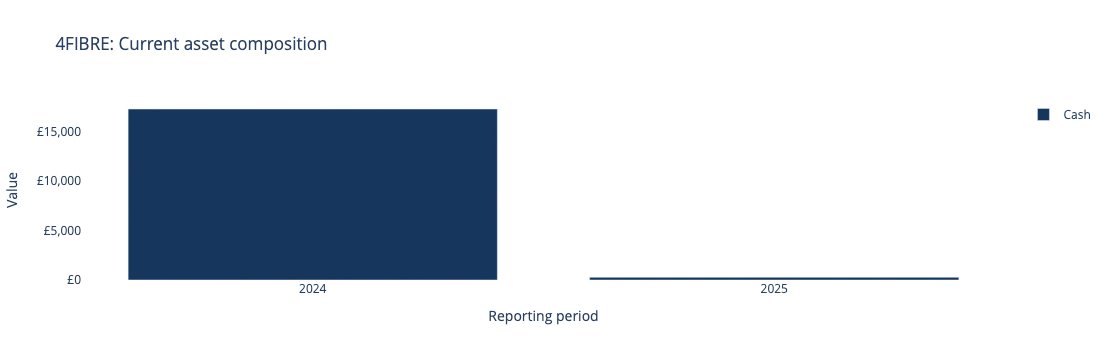

In [8]:
import plotly.express as px


asset_mix_plot = analysis_df.melt(
    id_vars=["reporting_date"],
    value_vars=["cash"],
    var_name="component",
    value_name="value",
)

asset_mix_plot["period"] = (
    asset_mix_plot["reporting_date"]
    .dt.strftime("%Y")
)

asset_mix_plot["component"] = (
    asset_mix_plot["component"]
    .map(
        {
            "cash": "Cash",
        }
    )
)

fig = px.bar(
    asset_mix_plot,
    x="period",
    y="value",
    color="component",
    barmode="stack",
    title="4FIBRE: Current asset composition",
    labels={
        "period": "Reporting period",
        "value": "Value",
        "component": "Component",
    },
    color_discrete_map={
        "Cash": "#17365D",
    },
)

fig.update_yaxes(
    tickprefix="£",
    tickformat=",.0f",
)

fig.update_layout(
    legend_title_text="",
    plot_bgcolor="white",
)

fig.show()


In [9]:
profit_plot = analysis_df[
    [
        "reporting_date",
        "profit_loss",
    ]
].copy()

profit_plot["period"] = (
    profit_plot["reporting_date"]
    .dt.strftime("%Y")
)

profit_plot["result"] = profit_plot["profit_loss"].apply(
    lambda value: "Profit" if value >= 0 else "Loss"
)

profit_plot

TypeError: '>=' not supported between instances of 'NoneType' and 'int'

In [10]:
profit_fig = px.bar(
    profit_plot,
    x="period",
    y="profit_loss",
    color="result",
    title="SCCI Group: Profit / (loss)",
    labels={
        "period": "Reporting period",
        "profit_loss": "Profit / (loss)",
        "result": "",
    },
    color_discrete_map={
        "Profit": "#2E7D32",
        "Loss": "#B42318",
    },
)

profit_fig.update_traces(
    texttemplate="£%{y:,.0f}",
    textposition="outside",
)

profit_fig.update_yaxes(
    tickprefix="£",
    tickformat=",.0f",
    zeroline=True,
    zerolinewidth=2,
    zerolinecolor="#555555",
)

profit_fig.update_layout(
    plot_bgcolor="white",
    showlegend=False,
)

profit_fig.show()

ValueError: Value of 'color' is not the name of a column in 'data_frame'. Expected one of ['reporting_date', 'profit_loss', 'period'] but received: result

In [9]:
profit_movement = (
    profit_plot
    .sort_values("reporting_date")["profit_loss"]
    .diff()
    .iloc[-1]
)

print(f"Adverse profit movement: £{abs(profit_movement):,.0f}")

Adverse profit movement: £2,640,895


In [10]:
ordered_df = analysis_df.sort_values("reporting_date")

prior = ordered_df.iloc[-2]
current = ordered_df.iloc[-1]

print("Prior period:", prior["reporting_date"])
print("Current period:", current["reporting_date"])

Prior period: 2024-05-31 00:00:00
Current period: 2025-05-31 00:00:00


In [11]:
import pandas as pd

kpi_summary = pd.DataFrame(
    [
        {
            "kpi": "Cash",
            "prior": prior["cash"],
            "current": current["cash"],
            "change": current["cash"] - prior["cash"],
            "unit": "GBP",
        },
        {
            "kpi": "Profit / (loss)",
            "prior": prior["profit_loss"],
            "current": current["profit_loss"],
            "change": current["profit_loss"] - prior["profit_loss"],
            "unit": "GBP",
        },
        {
            "kpi": "Net current position",
            "prior": prior["net_current_assets"],
            "current": current["net_current_assets"],
            "change": (
                current["net_current_assets"]
                - prior["net_current_assets"]
            ),
            "unit": "GBP",
        },
        {
            "kpi": "Current ratio",
            "prior": prior["current_ratio"],
            "current": current["current_ratio"],
            "change": current["current_ratio"] - prior["current_ratio"],
            "unit": "x",
        },
        {
            "kpi": "Debtors",
            "prior": prior["debtors"],
            "current": current["debtors"],
            "change": current["debtors"] - prior["debtors"],
            "unit": "GBP",
        },
        {
            "kpi": "Net assets",
            "prior": prior["net_assets"],
            "current": current["net_assets"],
            "change": current["net_assets"] - prior["net_assets"],
            "unit": "GBP",
        },
    ]
)

kpi_summary

,kpi,prior,current,change,unit
0,Cash,6.945326e+06,9.698804e+06,2.753478e+06,GBP
1,Profit / (loss),2.000139e+06,-6.407560e+05,-2.640895e+06,GBP
2,Net current position,-2.996933e+06,-3.707458e+06,-7.105250e+05,GBP
3,Current ratio,7.299204e-01,7.930269e-01,6.310650e-02,x
4,Debtors,1.154220e+06,4.506488e+06,3.352268e+06,GBP
5,Net assets,5.438743e+06,4.797987e+06,-6.407560e+05,GBP


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "analysis").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.calculate_kpis import load_reporting_data

four_fibre_data = load_reporting_data()

four_fibre_data

,company_name,company_number,reporting_date,cash,current_assets,debtors,profit_loss,net_current_assets,net_assets,average_employees,filing_date,accounts_date,source_url
0,4 FIBRE LIMITED,04144664,2024-05-31,17317.0,4445256.0,None,None,237003.0,237003.0,0.0,2026-02-26,2025-05-31,https://document-api.company-information.servi...
1,4 FIBRE LIMITED,04144664,2025-05-31,270.0,5257932.0,None,None,-74588.0,155452.0,0.0,2026-02-26,2025-05-31,https://document-api.company-information.servi...


In [4]:
from analysis.calculate_kpis import add_calculated_kpis

analysis_df = add_calculated_kpis(four_fibre_data)

non_zero_denominator_check = (
    analysis_df["current_liabilities"] != 0
).all()

print(
    "Liabilities is non-zero:",
    non_zero_denominator_check
)



analysis_df['current_ratio'] = (analysis_df['current_assets']/analysis_df['current_liabilities'])

analysis_df[
    [
    "reporting_date",
    "current_assets",
    "current_liabilities",
    "current_ratio",
    ]
].style.format(
    {
        "current_assets": "£{:,.0f}",
        "current_liabilities": "£{:,.0f}",
        "current_ratio": "{:,.2f}",
    }
)

Liabilities is non-zero: True


,reporting_date,current_assets,current_liabilities,current_ratio
0,2024-05-31 00:00:00,"£4,445,256","£4,208,253",1.06
1,2025-05-31 00:00:00,"£5,257,932","£5,332,520",0.99


In [5]:
analysis_df["cash_share_current_assets"] = (
    analysis_df["cash"]
    / analysis_df["current_assets"]
)

analysis_df[
    [
        "reporting_date",
        "cash",
        "current_assets",
        "cash_share_current_assets",
    ]
].style.format(
    {
        "cash": "£{:,.0f}",
        "current_assets": "£{:,.0f}",
        "cash_share_current_assets": "{:.1%}",
    }
)

,reporting_date,cash,current_assets,cash_share_current_assets
0,2024-05-31 00:00:00,"£17,317","£4,445,256",0.4%
1,2025-05-31 00:00:00,£270,"£5,257,932",0.0%
